In [2]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
parser = argparse.ArgumentParser()
parser.add_argument('--data_dir', type=str,
                    help='Data directory')
parser.add_argument('--error_df_name', type=str,
                    help='Error df name')
parser.add_argument('--sim_df_name', type=str,
                    help='Simulated data df name')
parser.add_argument('--split_ratios', nargs='+', type=float, default=[0.8, 0.2],
                    help='Train, val or train, val, test ratios')
args = parser.parse_args('')

In [4]:
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curves = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']

In [5]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=45):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]


    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/P_o[i]
        gamma.append(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [114]:
# define constant
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

## unused constant
l_ext = Decimal(400)
V = Decimal(25)

In [122]:
len(list(range(22000, 1300000, 2000)))

639

In [123]:
beta = Decimal(25)
D_inits = [1, 10, 40, 100, 1000, 10000, 100000]
P_inits = list(range(22000, 1300000, 2000)) #[2.2e4, 2.5e4, 7.5e4, 1e5, 2.5e5, 5e5, 7.5e5, 1e6, 1.3e6]
E_inits = [1e6] # [Decimal(12.6e11), Decimal(6.3e11), Decimal(2.1e11)]
delta_es = [100] #[Decimal(5), Decimal
prop_cons = [1]

In [124]:

error_df = pd.DataFrame()
sim_df = pd.DataFrame()
for delta_e in delta_es:
    for D_init in D_inits:
        for P_init in P_inits:
            for E_init in E_inits:
                
                print('Working on D_init = {}, P_init = {}, E_init = {}, delta_e = {}'.format(D_init, P_init, E_init, delta_e))
                try:
                    D_init = Decimal(D_init)
                    E_init = Decimal(E_init)
                    P_init = Decimal(P_init)
                    delta_e = Decimal(delta_e)

                    eff, n_a, D_e, S_o, E_o, P_o, gamma, delta = simulate_vals(D_init=D_init,
                                                                                E_init=E_init,
                                                                                P_init=P_init,
                                                                                delta_e=delta_e,
                                                                                n_d=n_d,
                                                                                n_dE=n_dE,
                                                                                k_C=k_C,
                                                                                beta=beta,
                                                                                n_cycle=45)
                    for prop in prop_cons:
                        prop = Decimal(prop)
                        if D_e[-1]*prop <= 3000000:
                            print('Work on proportion constant = ', prop)
                            F_n = [d*prop for d in D_e]
                            sim_df = pd.concat([sim_df, pd.DataFrame({'E_init': E_init,
                                                                'D_init': D_init,
                                                                'P_init': P_init,
                                                                'delta_e': delta_e,
                                                                'prop_const': prop,
                                                                'E_o': E_o,
                                                                'D_e': D_e,
                                                                'S_o': [np.nan] + S_o,
                                                                'P_o': P_o,
                                                                'delta_e': delta_e,
                                                                'cycle_no': range(len(E_o)),
                                                                'gamma': [np.nan] + gamma,
                                                                'delta': [np.nan] + delta,
                                                                'n_a': [np.nan] + n_a,
                                                                'eff': [np.nan] + eff,
                                                                'Fn': F_n
                                                                })])
                except Exception as e:
                    print(e)
                    error_df = pd.concat([error_df, pd.DataFrame({'E_init': [E_init],
                                                                    'D_init': [D_init],
                                                                    'P_init': [P_init],
                                                                    'delta_e': [delta_e],
                                                                    'prop_const': prop})])


Working on D_init = 1, P_init = 22000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 24000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 26000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 28000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 30000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 32000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 34000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 36000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 38000, E_init = 1000000.0, delta_e = 100
Work on proportion constant =  1
Working on D_init = 1, P_init = 40000, E_init 

In [147]:
len(list(range(10)))

10

In [150]:
sim_df.loc[:,'idx'] = sim_df.groupby(['E_init','D_init','P_init','delta_e','prop_const']).ngroup()

In [151]:
sim_df.head()

,E_init,D_init,P_init,delta_e,prop_const,E_o,D_e,S_o,P_o,cycle_no,gamma,delta,n_a,eff,Fn,idx
0,1000000,1,22000,100,1,1000000,1,NaN,22000,0,NaN,NaN,NaN,NaN,1,0
1,1000000,1,22000,100,1,989999.9999999999911182158030,1.999432239664153614034310000,1,21999.00056776033584638596569,1,0.00004545454545454545454545454545,21999.00056776033584638596569,0.99943223966415361403431,0.9994322396641536140343100000,1.999432239664153614034310000,0
2,1000000,1,22000,100,1,980099.9999999999824140672899,3.996596305549034864358153315,1.999432239664153614034310000,21997.00340369445096513564185,2,0.00009088741252156396911596553274,11001.62484495563946146248894,0.99886559107416745923412,0.9988655910741674592341200000,3.996596305549034864358153315,0
3,1000000,1,22000,100,1,970298.9999999999738848899256,7.984142777161432070691883496,3.996596305549034864358153315,21993.01585722283856792930812,3,0.0001816882159902651403617615166,5502.936542949522280934874665,0.997735614696917848562468,0.9977356146969178485624680000,7.984142777161432070691883496,0
4,1000000,1,22000,100,1,960596.0099999999655280547017,15.93226784889009558385817154,7.984142777161432070691883496,21985.06773215110990441614183,4,0.0003630308289228700300418521854,2753.591505783087516772496781,0.995488845022186116595255,0.9954888450221861165952550000,15.93226784889009558385817154,0


In [152]:
sim_df.to_csv('./data/sim_data.csv', index=False)

### Try out a single curve

In [139]:
beta = Decimal(5)
D_inits = Decimal(10000) # 1 - 10000
P_inits = Decimal(6e12) # 2.2e4 - 1.3e6
E_inits = Decimal(1e12)
delta_es = Decimal(5)

# D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=45
D_e = simulate_vals(D_init=D_inits, 
                    E_init=E_inits, 
                    P_init=P_inits, 
                    delta_e=delta_es,
                    n_d=n_d,
                    n_dE=n_dE,
                    k_C=k_C,
                    beta=beta)[2]

In [140]:
max(D_e)

Decimal('6000000009999.999999999492940')

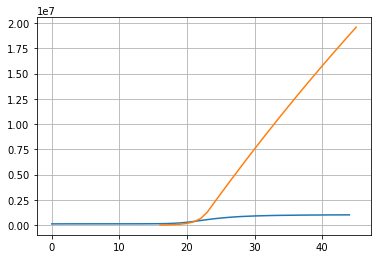

In [133]:
curves.plot()
plt.plot(range(16,46), D_e[:30])
plt.grid()
# plt.xticks(range(0,30,5))